# Tree

## Deterministic

method          condition        n_obj  seeds      mean       std       min       max
PQL-Pareto      observable           2     10   0.99989   0.00012   0.99960   0.99999
PQL-Indicator   observable           2     10   0.99999   0.00001   0.99997   0.99999
PQL-Decomp      observable           2     10   0.99816   0.00000   0.99816   0.99816
NSGA-II         observable           2     10   0.99997   0.00000   0.99997   0.99998
NSGA-II         non-observable       2     10   0.82818   0.00000   0.82818   0.82818
IBEA            observable           2     10   0.99991   0.00005   0.99979   0.99998
IBEA            non-observable       2     10   0.82817   0.00001   0.82816   0.82818
MOEA/D          observable           2     10   0.99906   0.00029   0.99845   0.99944
MOEA/D          non-observable       2     10   0.82777   0.00018   0.82737   0.82798
PQL-Pareto      observable           6     10   0.99629   0.00172   0.99257   0.99847
PQL-Indicator   observable           6     10   0.9970

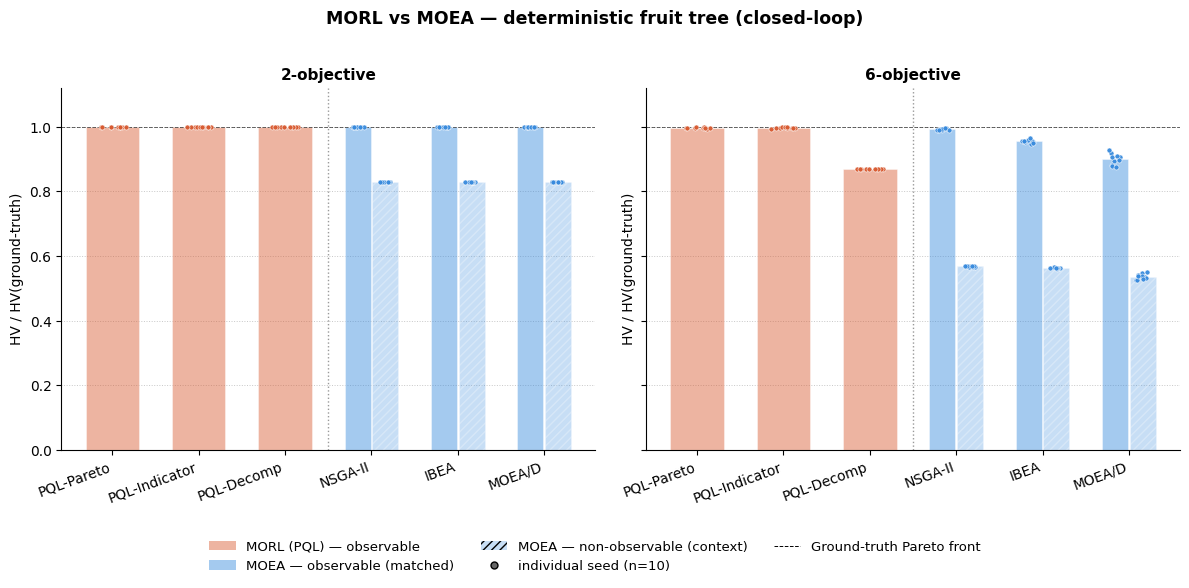

In [6]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from morl_baselines.common.performance_indicators import hypervolume

MORL_METHODS = ["pareto", "indicator", "decomposition"]
MOEA_METHODS = ["NSGAII", "IBEA", "MOEAD"]
ORDER = MORL_METHODS + MOEA_METHODS
METHOD_LABEL = {
    "pareto": "PQL-Pareto", "indicator": "PQL-Indicator", "decomposition": "PQL-Decomp",
    "NSGAII": "NSGA-II", "IBEA": "IBEA", "MOEAD": "MOEA/D",
}
PARADIGM_OF = {**{m: "MORL" for m in MORL_METHODS},
               **{m: "MOEA" for m in MOEA_METHODS}}
PARADIGM_COLOR = {"MORL": "#D85A30", "MOEA": "#378ADD"}
N_OBJS = [2, 6]

# Conditions per paradigm. MORL has the single inherent condition; MOEA has two.
MORL_CONDITIONS = ["observable"]
MOEA_CONDITIONS = ["observable", "non_observable"]
# Per-condition bar styling (hue still comes from the paradigm).
COND_STYLE = {
    "observable":     dict(alpha=0.45, hatch=""),
    "non_observable": dict(alpha=0.28, hatch="////"),
}
COND_LABEL = {"observable": "observable", "non_observable": "non-observable"}


def _conditions_for(method):
    return MORL_CONDITIONS if PARADIGM_OF[method] == "MORL" else MOEA_CONDITIONS


def _hv_of_csv(path, obj_is_negative, ref_value=-1.0):
    df = pd.read_csv(path)
    obj_cols = [c for c in df.columns if re.match(r'^o\d+$', c)]
    vals = np.abs(df[obj_cols].values) if obj_is_negative else df[obj_cols].values
    if len(vals) == 0:
        return 0.0
    ref = np.full(len(obj_cols), ref_value)
    return hypervolume(ref, [tuple(r) for r in vals])


def _gt_hv(tree_csv_dir, n_obj, ref_value=-1.0):
    df = pd.read_csv(os.path.join(tree_csv_dir, f'depth9_dim{n_obj}.csv'))
    r_cols = [f'r{i}' for i in range(n_obj)]
    pf = df[df['ground_truth_pareto'] == 1][r_cols].values
    return hypervolume(np.full(n_obj, ref_value), [tuple(r) for r in pf])


def _seed_of(name):
    m = re.search(r'_seed(\d+)$', name)
    return int(m.group(1)) if m else None


def load_seed_values(moea_base, morl_base, tree_csv_dir, ref_value=-1.0):
    """Return {(method, condition, n_obj): np.array of per-seed hv_ratio}."""
    out = {}
    for n_obj in N_OBJS:
        gt = _gt_hv(tree_csv_dir, n_obj, ref_value)

        # ── MORL: pcs_*.csv, positive (MAX-convention) objectives ──
        for scoring in MORL_METHODS:
            group = os.path.join(morl_base, f'{scoring}_single_{n_obj}')
            ratios = []
            for seed_folder in sorted(os.listdir(group)):
                sd = os.path.join(group, seed_folder)
                if not os.path.isdir(sd):
                    continue
                pcs = [f for f in os.listdir(sd) if f.startswith('pcs_')]
                if not pcs:
                    continue
                hv = _hv_of_csv(os.path.join(sd, pcs[0]),
                                obj_is_negative=False, ref_value=ref_value)
                ratios.append(hv / gt)
            out[(scoring, "observable", n_obj)] = np.array(ratios)

        # ── MOEA: archives_*.csv, negative objectives, two conditions ──
        for algo in MOEA_METHODS:
            for cond in MOEA_CONDITIONS:
                group = os.path.join(
                    moea_base, f'table_{algo}_single_{n_obj}_{cond}')
                ratios = []
                if os.path.isdir(group):
                    for seed_folder in sorted(os.listdir(group)):
                        sd = os.path.join(group, seed_folder)
                        if not os.path.isdir(sd):
                            continue
                        arch = [f for f in os.listdir(sd)
                                if f.startswith('archives_')
                                and f.endswith('.csv')]
                        if not arch:
                            continue
                        hv = _hv_of_csv(os.path.join(sd, arch[0]),
                                        obj_is_negative=True,
                                        ref_value=ref_value)
                        ratios.append(hv / gt)
                out[(algo, cond, n_obj)] = np.array(ratios)
    return out


def plot_panel(ax, data, n_obj, title):
    x = np.arange(len(ORDER))
    rng = np.random.default_rng(42)
    sub_w = 0.30          # width of a single sub-bar (MOEA, 2 conditions)
    solo_w = 0.62         # width of a solo bar (MORL, 1 condition)
    sub_off = 0.16        # +/- offset of MOEA sub-bars from the method centre

    for i, method in enumerate(ORDER):
        color = PARADIGM_COLOR[PARADIGM_OF[method]]
        conds = _conditions_for(method)
        for ci, cond in enumerate(conds):
            vals = data.get((method, cond, n_obj), np.array([]))
            if len(vals) == 0:
                continue
            if len(conds) == 1:
                bx, bw = i, solo_w
            else:
                bx = i + (ci - (len(conds) - 1) / 2.0) * (2 * sub_off)
                bw = sub_w
            style = COND_STYLE[cond]
            ax.bar(bx, vals.mean(), width=bw, color=color,
                   alpha=style["alpha"], edgecolor='white', linewidth=0.6,
                   hatch=style["hatch"], zorder=2)
            if len(vals) > 1:
                jitter = rng.uniform(-bw * 0.26, bw * 0.26, size=len(vals))
                ax.scatter(bx + jitter, vals, s=13, color=color,
                           edgecolor='white', linewidth=0.4, zorder=3,
                           alpha=0.95)

    ax.axvline(len(MORL_METHODS) - 0.5, color='0.6', linestyle=':',
               linewidth=1.0)
    ax.axhline(1.0, color='black', linestyle='--', linewidth=0.7, alpha=0.6)

    # Full shared range. The observable methods cluster near 1.0; the
    # non-observable MOEA bars sit well below, and that gap is the point of
    # the panel — a tight zoom would hide it, so the axis is not zoomed.
    ax.set_ylim(0, 1.12)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('HV / HV(ground-truth)', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABEL[m] for m in ORDER], rotation=20,
                       ha='right')
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


if __name__ == '__main__':
    MOEA_BASE = './tree_data/deterministic/moea'
    MORL_BASE = './tree_data/deterministic/morl'
    TREE_CSV_DIR = './trees'
    OUT = './tree_figures'

    data = load_seed_values(MOEA_BASE, MORL_BASE, TREE_CSV_DIR)

    # Numeric summary
    print(f"{'method':<16}{'condition':<16}{'n_obj':>6}{'seeds':>7}"
          f"{'mean':>10}{'std':>10}{'min':>10}{'max':>10}")
    for n_obj in N_OBJS:
        for m in ORDER:
            for c in _conditions_for(m):
                v = data.get((m, c, n_obj), np.array([]))
                if len(v) == 0:
                    print(f"{METHOD_LABEL[m]:<16}{COND_LABEL[c]:<16}"
                          f"{n_obj:>6}{0:>7}{'--':>10}")
                    continue
                std = v.std(ddof=1) if len(v) > 1 else 0.0
                print(f"{METHOD_LABEL[m]:<16}{COND_LABEL[c]:<16}{n_obj:>6}"
                      f"{len(v):>7}{v.mean():>10.5f}{std:>10.5f}"
                      f"{v.min():>10.5f}{v.max():>10.5f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig.suptitle('MORL vs MOEA — deterministic fruit tree (closed-loop)',
                 fontsize=12.5, fontweight='bold', y=1.02)
    plot_panel(ax1, data, 2, '2-objective')
    plot_panel(ax2, data, 6, '6-objective')

    handles = [
        Patch(facecolor=PARADIGM_COLOR['MORL'],
              alpha=COND_STYLE['observable']['alpha'],
              label='MORL (PQL) — observable'),
        Patch(facecolor=PARADIGM_COLOR['MOEA'],
              alpha=COND_STYLE['observable']['alpha'],
              label='MOEA — observable (matched)'),
        Patch(facecolor=PARADIGM_COLOR['MOEA'],
              alpha=COND_STYLE['non_observable']['alpha'], hatch='////',
              label='MOEA — non-observable (context)'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='0.4',
               markersize=5, label='individual seed (n=10)'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=0.7,
               label='Ground-truth Pareto front'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.13), frameon=False, fontsize=9.5)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT, 'fig1_morl_vs_moea_seeds.png'),
                dpi=150, bbox_inches='tight')
    print(f"\nSaved {OUT}/fig1_morl_vs_moea_seeds.png")

Loaded 6 convergence curve(s) across 6 cells
No seed dimension in folder names — plotting single curves without bands.
Saved ./tree_figures/morl_convergence_pcs_size.png


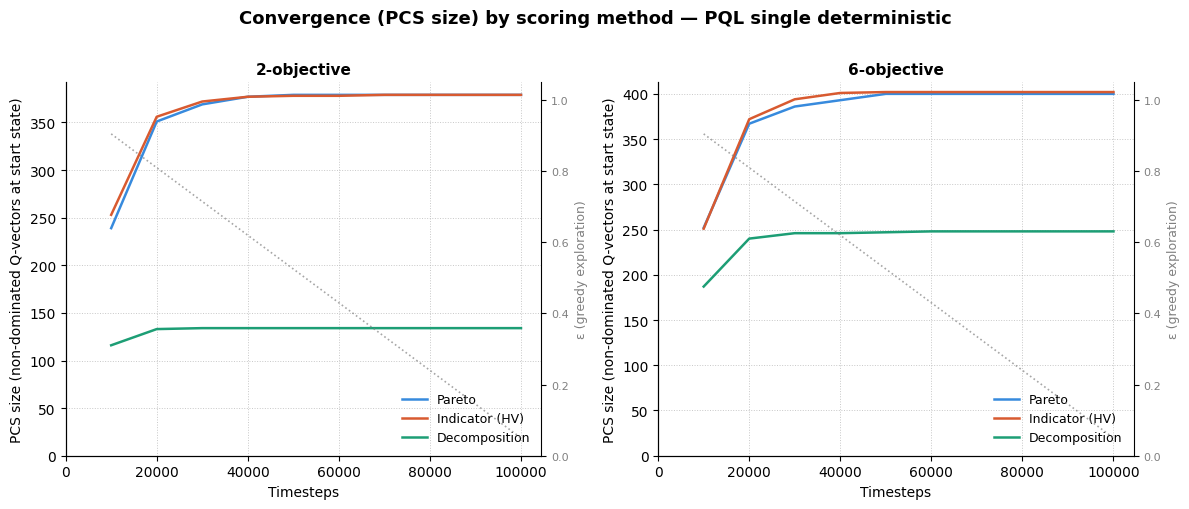

In [13]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Style config (mirrors plot_morl_hv.py) ────────────────────────────────────
SCORING_LABELS = {
    "pareto":        "Pareto",
    "indicator":     "Indicator (HV)",
    "decomposition": "Decomposition",
}
SCORING_COLORS = {
    "pareto":        "#378ADD",
    "indicator":     "#D85A30",
    "decomposition": "#1D9E75",
}

SCORINGS = ["pareto", "indicator", "decomposition"]
N_OBJS   = [2, 6]

FOLDER_RE = re.compile(
    r'^(pareto|indicator|decomposition)_single_(\d+)(?:_seed(\d+))?$'
)


# ── Loader ────────────────────────────────────────────────────────────────────
def _convergence_csv(folder_path):
    files = os.listdir(folder_path)
    convs = sorted(f for f in files
                   if f.startswith('convergence_') and f.endswith('.csv'))
    return convs[0] if convs else None


def load_convergences(base):
    """Walk `base`, collect (scoring, n_obj, seed, df) tuples. df has columns:
    timestep, pcs_size, epsilon.
    """
    records = []
    for d in sorted(os.listdir(base)):
        m = FOLDER_RE.match(d)
        if not m:
            continue
        scoring, n_obj, seed = m.groups()
        n_obj = int(n_obj)
        seed = int(seed) if seed is not None else None

        folder_path = os.path.join(base, d)
        csv_name = _convergence_csv(folder_path)
        if csv_name is None:
            continue
        df = pd.read_csv(os.path.join(folder_path, csv_name))
        needed = {'timestep', 'pcs_size', 'epsilon'}
        if not needed.issubset(df.columns):
            continue
        records.append({
            'scoring': scoring,
            'n_obj': n_obj,
            'seed': seed,
            'df': df[['timestep', 'pcs_size', 'epsilon']].copy(),
        })
    return records


def aggregate_curves(records, scoring, n_obj, value_col):
    """Collect curves matching the given cell. Returns (grid, mean, std).
    With one seed, the original curve is returned and std is zero.
    """
    matching = [r for r in records
                if r['scoring'] == scoring and r['n_obj'] == n_obj]
    if not matching:
        return None, None, None

    if len(matching) == 1:
        df = matching[0]['df']
        return df['timestep'].values, df[value_col].values, np.zeros(len(df))

    max_ts = max(r['df']['timestep'].max() for r in matching)
    common_grid = np.linspace(
        min(r['df']['timestep'].min() for r in matching),
        max_ts, 200,
    )
    interpolated = []
    for r in matching:
        df = r['df']
        y = np.interp(common_grid, df['timestep'].values, df[value_col].values)
        interpolated.append(y)
    arr = np.array(interpolated)
    return common_grid, arr.mean(axis=0), arr.std(axis=0)


# ── Plotting ──────────────────────────────────────────────────────────────────
def plot_convergence_panel(ax, records, n_obj, title, show_epsilon=True):
    """One panel: x = timestep, y = pcs_size, one line per scoring method."""
    has_data = False
    for scoring in SCORINGS:
        grid, mean, std = aggregate_curves(records, scoring, n_obj, 'pcs_size')
        if grid is None:
            continue
        has_data = True
        color = SCORING_COLORS[scoring]
        ax.plot(grid, mean, color=color, linewidth=1.8,
                label=SCORING_LABELS[scoring])
        if (std > 0).any():
            ax.fill_between(grid, mean - std, mean + std,
                            color=color, alpha=0.2, linewidth=0)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Timesteps', fontsize=10)
    ax.set_ylabel('PCS size (non-dominated Q-vectors at start state)', fontsize=10)
    ax.grid(linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

    # Overlay ε-greedy decay on a secondary axis. Use one representative curve
    # (epsilon decay is the same across scoring methods at the same n_obj).
    if show_epsilon and has_data:
        for scoring in SCORINGS:
            grid, mean, _ = aggregate_curves(records, scoring, n_obj, 'epsilon')
            if grid is not None:
                ax2 = ax.twinx()
                ax2.plot(grid, mean, color='gray', linestyle=':',
                         linewidth=1.2, alpha=0.7)
                ax2.set_ylabel('ε (greedy exploration)', fontsize=9, color='gray')
                ax2.tick_params(axis='y', labelcolor='gray', labelsize=8)
                ax2.set_ylim(0, 1.05)
                ax2.spines[['top']].set_visible(False)
                break

    if has_data:
        ax.legend(fontsize=9, loc='lower right', frameon=False)


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    BASE = './tree_data/morl_deterministic'
    OUT = './tree_figures'
    os.makedirs(OUT, exist_ok=True)

    records = load_convergences(BASE)
    if not records:
        raise SystemExit(f'No convergence data found under {BASE}')

    n_cells = len({(r['scoring'], r['n_obj']) for r in records})
    print(f'Loaded {len(records)} convergence curve(s) across {n_cells} cells')
    has_seed = any(r['seed'] is not None for r in records)
    if has_seed:
        from collections import Counter
        seeds_per_cell = Counter((r['scoring'], r['n_obj']) for r in records)
        print(f'Seeds per cell: min={min(seeds_per_cell.values())}, '
              f'max={max(seeds_per_cell.values())}')
    else:
        print('No seed dimension in folder names — plotting single curves without bands.')

    # Layout: cols = n_obj. 1 × 2 = 2 panels.
    fig, axes = plt.subplots(1, len(N_OBJS), figsize=(12, 5))
    fig.suptitle(
        'Convergence (PCS size) by scoring method — PQL single deterministic',
        fontsize=13, fontweight='bold', y=1.01,
    )

    for j, n_obj in enumerate(N_OBJS):
        plot_convergence_panel(axes[j], records, n_obj, title=f'{n_obj}-objective')

    fig.tight_layout()
    out_path = os.path.join(OUT, 'morl_convergence_pcs_size.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

## Robustness

Loaded 24 evaluated archive(s) across 24 cells
Cells (condition, algo, n_obj):
  intertemporal_moro     IBEA    n_obj=2  pts=  27  hv= 85.2876  runtime= 294s
  intertemporal_moro     IBEA    n_obj=6  pts= 128  hv=38305.4226  runtime= 616s
  intertemporal_multi    IBEA    n_obj=2  pts=  88  hv= 88.9897  runtime= 300s
  intertemporal_multi    IBEA    n_obj=6  pts= 379  hv=44398.8800  runtime= 975s
  intertemporal_moro     MOEAD   n_obj=2  pts=  23  hv= 84.9005  runtime= 254s
  intertemporal_moro     MOEAD   n_obj=6  pts= 128  hv=37486.7497  runtime= 402s
  intertemporal_multi    MOEAD   n_obj=2  pts=  86  hv= 88.9833  runtime= 356s
  intertemporal_multi    MOEAD   n_obj=6  pts= 387  hv=44367.6048  runtime= 699s
  intertemporal_moro     NSGAII  n_obj=2  pts=  28  hv= 85.3214  runtime= 231s
  intertemporal_moro     NSGAII  n_obj=6  pts= 176  hv=39916.9364  runtime= 292s
  intertemporal_multi    NSGAII  n_obj=2  pts=  88  hv= 88.9897  runtime= 141s
  intertemporal_multi    NSGAII  n_obj=6  

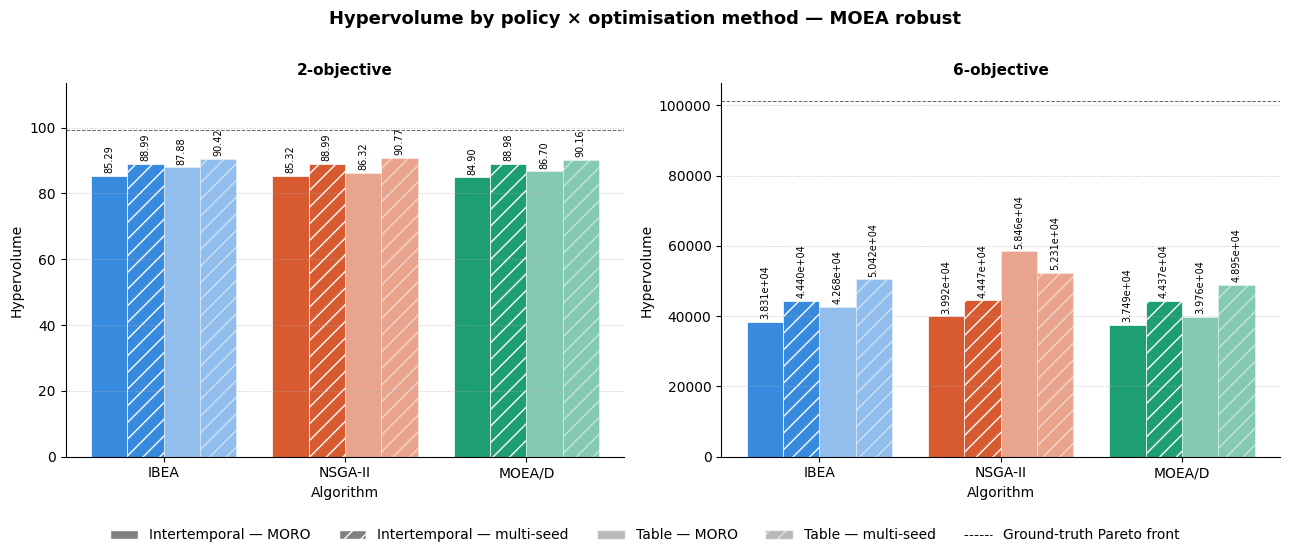

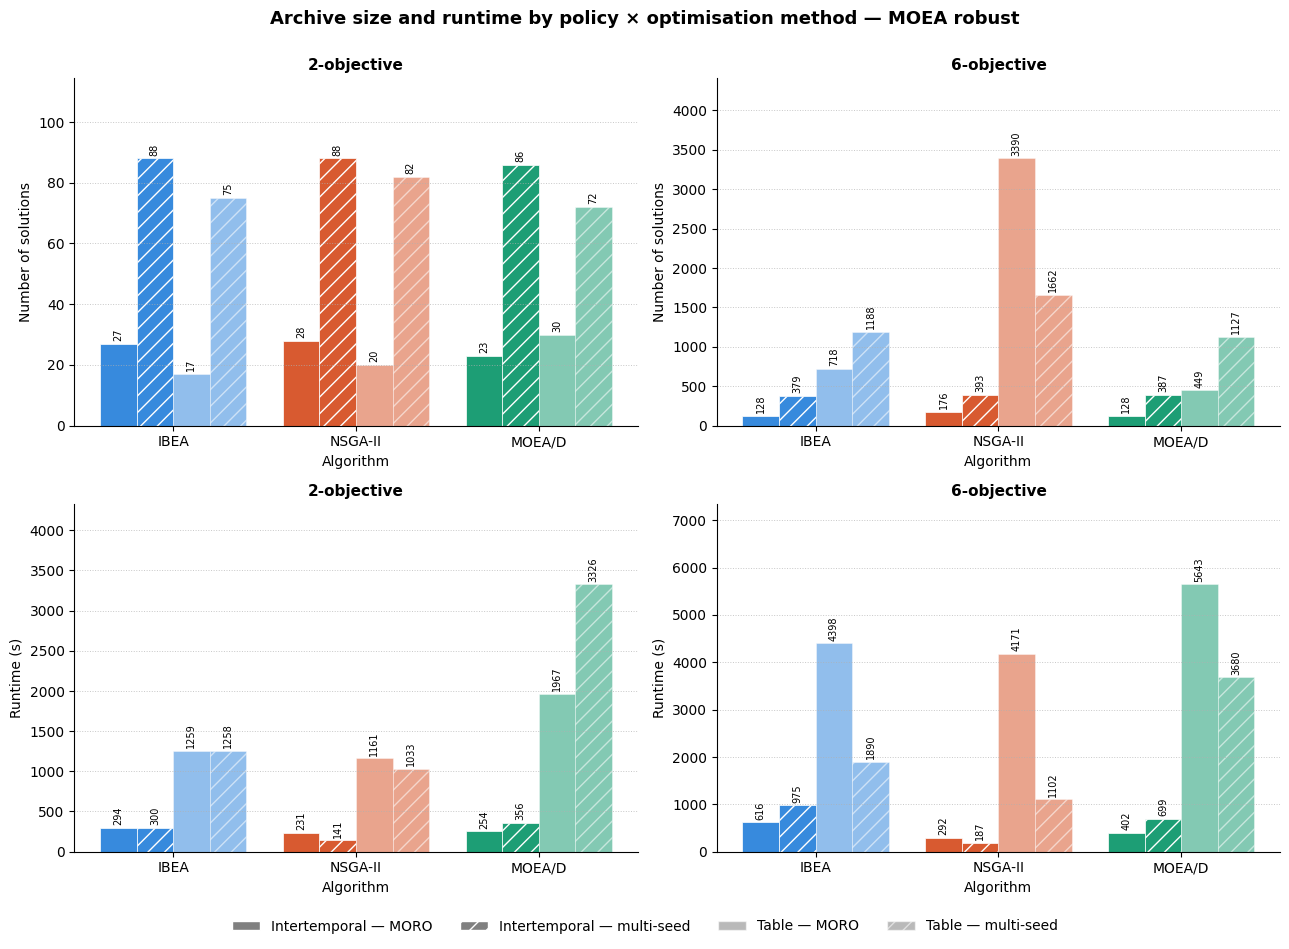

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from morl_baselines.common.performance_indicators import hypervolume

ALGO_LABELS = {"IBEA": "IBEA", "NSGAII": "NSGA-II", "MOEAD": "MOEA/D"}
ALGO_COLORS = {"IBEA": "#378ADD", "NSGAII": "#D85A30", "MOEAD": "#1D9E75"}

COND_LABEL = {
    "intertemporal_moro":  "Intertemporal — MORO",
    "intertemporal_multi": "Intertemporal — Multi",
    "table_moro":          "Table — MORO",
    "table_multi":         "Table — Multi",
}

COND_ALPHA = {
    "intertemporal_moro":  1.0,
    "intertemporal_multi": 1.0,
    "table_moro":          0.55,
    "table_multi":         0.55,
}
COND_HATCH = {
    "intertemporal_moro":  "",
    "intertemporal_multi": "//",
    "table_moro":          "",
    "table_multi":         "//",
}

ALGOS      = ["IBEA", "NSGAII", "MOEAD"]
CONDITIONS = ["intertemporal_moro", "intertemporal_multi",
              "table_moro",         "table_multi"]
N_OBJS     = [2, 6]


FOLDER_RE = re.compile(
    r'^(intertemporal|table)_(NSGAII|IBEA|MOEAD)_(moro|multi)_(\d+)_observable$'
)

OBJ_COL_RE = re.compile(r'^o\d+(_mean)?$')


def _evaluated_csv(folder_path):
    files = os.listdir(folder_path)
    evaluated = sorted(f for f in files
                       if f.startswith('archives_') and f.endswith('_evaluated.csv'))
    return evaluated[0] if evaluated else None


def _compute_hv(df, ref_value=-1.0):
    obj_cols = [c for c in df.columns if OBJ_COL_RE.match(c)]
    if not obj_cols:
        return None, 0
    vals = np.abs(df[obj_cols].values)
    if len(vals) == 0:
        return 0.0, 0
    ref = np.full(len(obj_cols), ref_value)
    return hypervolume(ref, [tuple(r) for r in vals]), len(vals)


def load_ground_truth_hv(tree_csv_dir, ref_value=-1.0):
    out = {}
    for n_obj in N_OBJS:
        path = os.path.join(tree_csv_dir, f'depth9_dim{n_obj}.csv')
        if not os.path.exists(path):
            print(f'WARNING: ground-truth file not found: {path}')
            continue
        df = pd.read_csv(path)
        r_cols = [f'r{i}' for i in range(n_obj)]
        pf = df[df['ground_truth_pareto'] == 1][r_cols].values
        if len(pf) == 0:
            print(f'WARNING: no ground-truth Pareto front in {path}')
            continue
        ref = np.full(n_obj, ref_value)
        out[n_obj] = hypervolume(ref, [tuple(r) for r in pf])
    return out


def _parse_runtime_seconds(folder_path):
    files = os.listdir(folder_path)
    convs = sorted(f for f in files
                   if f.startswith('convergences_') and f.endswith('.csv'))
    if not convs:
        return None

    last_seconds = []
    for c in convs:
        df = pd.read_csv(os.path.join(folder_path, c))
        if 'time' not in df.columns or len(df) == 0:
            continue
        last = str(df['time'].iloc[-1])
        try:
            h, m, s = map(int, last.split(':'))
            last_seconds.append(h * 3600 + m * 60 + s)
        except (ValueError, AttributeError):
            continue

    return max(last_seconds) if last_seconds else None


def load_dataset(base, ref_value=-1.0):
    records = []
    for d in sorted(os.listdir(base)):
        m = FOLDER_RE.match(d)
        if not m:
            continue
        policy, algo, method, n_obj = m.groups()
        n_obj = int(n_obj)
        condition = f"{policy}_{method}"
        if condition not in CONDITIONS:
            continue

        folder_path = os.path.join(base, d)
        csv_name = _evaluated_csv(folder_path)
        if csv_name is None:
            print(f'WARNING: no *_evaluated.csv in {folder_path}, skipping')
            continue

        df = pd.read_csv(os.path.join(folder_path, csv_name))
        hv, n_points = _compute_hv(df, ref_value=ref_value)
        if hv is None:
            print(f'WARNING: no objective columns in {csv_name}, skipping')
            continue

        runtime_s = _parse_runtime_seconds(folder_path)
        records.append({
            'condition': condition, 'algo': algo, 'method': method,
            'policy': policy, 'n_obj': n_obj,
            'hv': hv, 'n_points': n_points,
            'runtime_s': runtime_s,
        })
    return pd.DataFrame(records)


def aggregate(df, gt_hv=None):
    grouped = df.groupby(['condition', 'algo', 'n_obj']).agg(
        hv_mean=('hv', 'mean'),
        hv_std=('hv', 'std'),
        n_seeds=('hv', 'count'),
        n_points_mean=('n_points', 'mean'),
        n_points_std=('n_points', 'std'),
        runtime_mean=('runtime_s', 'mean'),
        runtime_std=('runtime_s', 'std'),
    ).reset_index()
    grouped['hv_std'] = grouped['hv_std'].fillna(0.0)
    grouped['n_points_std'] = grouped['n_points_std'].fillna(0.0)
    grouped['runtime_std'] = grouped['runtime_std'].fillna(0.0)

    if gt_hv:
        grouped['hv_ratio'] = grouped.apply(
            lambda r: r['hv_mean'] / gt_hv[r['n_obj']]
                      if r['n_obj'] in gt_hv else np.nan,
            axis=1,
        )
        grouped['hv_ratio_std'] = grouped.apply(
            lambda r: r['hv_std'] / gt_hv[r['n_obj']]
                      if r['n_obj'] in gt_hv else np.nan,
            axis=1,
        )

    return grouped


def plot_bars(ax, agg, n_obj, title, metric='hv', gt_hv=None):
    subset = agg[agg['n_obj'] == n_obj]
    x = np.arange(len(ALGOS))
    width = 0.20
    n_cond = len(CONDITIONS)
    offsets = (np.arange(n_cond) - (n_cond - 1) / 2.0) * width

    has_variance = (subset['n_seeds'] > 1).any()

    if metric == 'hv':
        mean_col, std_col, ylabel = 'hv_mean', 'hv_std', 'Hypervolume'
        label_fmt = lambda v: f'{v:#.4g}'
    elif metric == 'hv_ratio':
        mean_col, std_col, ylabel = 'hv_ratio', 'hv_ratio_std', 'HV / HV(ground-truth)'
        label_fmt = lambda v: f'{v:.4f}'
    elif metric == 'n_points':
        mean_col, std_col, ylabel = 'n_points_mean', 'n_points_std', 'Number of solutions'
        label_fmt = lambda v: f'{v:.0f}'
    elif metric == 'runtime':
        mean_col, std_col, ylabel = 'runtime_mean', 'runtime_std', 'Runtime (s)'
        label_fmt = lambda v: f'{v:.0f}'
    else:
        raise ValueError(
            f"metric must be 'hv', 'hv_ratio', 'n_points', or 'runtime'; "
            f"got {metric!r}"
        )

    for offset, cond in zip(offsets, CONDITIONS):
        means, stds = [], []
        for algo in ALGOS:
            row = subset[(subset['algo'] == algo) & (subset['condition'] == cond)]
            if len(row) == 0:
                means.append(0.0)
                stds.append(0.0)
            else:
                means.append(float(row[mean_col].iloc[0]))
                stds.append(float(row[std_col].iloc[0]))

        bars = ax.bar(
            x + offset, means, width=width,
            yerr=stds if has_variance else None,
            capsize=3 if has_variance else 0,
            label=COND_LABEL[cond],
            color=[ALGO_COLORS[a] for a in ALGOS],
            alpha=COND_ALPHA[cond],
            edgecolor='white', linewidth=0.5,
            hatch=COND_HATCH[cond],
            error_kw={'ecolor': '0.3', 'linewidth': 0.8} if has_variance else {},
        )
        ax.bar_label(
            bars,
            labels=[label_fmt(v) for v in means],
            padding=2, fontsize=7, rotation=90,
        )

    if metric == 'hv_ratio':
        ax.set_ylim(0, 1.12)
        ax.axhline(1.0, color='black', linestyle='--', linewidth=0.7,
                   alpha=0.6, label='Ground-truth Pareto front')
    elif metric == 'hv':
        max_val = (subset[mean_col] + subset[std_col]).max() if not subset.empty else 1.0
        ymax = max(max_val * 1.25, gt_hv * 1.05 if gt_hv else 0.0)
        ax.set_ylim(0, ymax)
        if gt_hv is not None:
            ax.axhline(gt_hv, color='black', linestyle='--', linewidth=0.7,
                       alpha=0.6, label='Ground-truth Pareto front')
    else:
        max_val = (subset[mean_col] + subset[std_col]).max() if not subset.empty else 1.0
        ax.set_ylim(0, max_val * 1.30)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Algorithm', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([ALGO_LABELS[a] for a in ALGOS])
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


def _build_legend_handles(include_gt=False):
    handles = [
        Patch(facecolor='grey', alpha=COND_ALPHA[c], hatch=COND_HATCH[c],
              edgecolor='white', label=COND_LABEL[c])
        for c in CONDITIONS
    ]
    if include_gt:
        from matplotlib.lines import Line2D
        handles.append(
            Line2D([0], [0], color='black', linestyle='--', linewidth=0.7,
                   label='Ground-truth Pareto front')
        )
    return handles


if __name__ == '__main__':
    BASE = './tree_data/moea_robust'
    TREE_CSV_DIR = './trees'
    OUT = './tree_figures'
    REF_VALUE = -1.0
    METRIC = 'hv'

    os.makedirs(OUT, exist_ok=True)

    raw = load_dataset(BASE, ref_value=REF_VALUE)
    if raw.empty:
        raise SystemExit(f'No data found under {BASE}')

    n_cells = len(raw[['condition', 'algo', 'n_obj']].drop_duplicates())
    print(f'Loaded {len(raw)} evaluated archive(s) across {n_cells} cells')
    print('Cells (condition, algo, n_obj):')
    for _, r in raw[['condition', 'algo', 'n_obj', 'n_points', 'hv',
                     'runtime_s']].iterrows():
        rt = f'{r.runtime_s:>4d}s' if r.runtime_s is not None else '   ?'
        print(f'  {r.condition:<22s} {r.algo:<7s} n_obj={r.n_obj}  '
              f'pts={r.n_points:>4d}  hv={r.hv:8.4f}  runtime={rt}')

    gt_hv = load_ground_truth_hv(TREE_CSV_DIR, ref_value=REF_VALUE)
    if gt_hv:
        for n_obj, hv in gt_hv.items():
            print(f'  Ground-truth HV (n_obj={n_obj}): {hv:.4f}')
    elif METRIC == 'hv_ratio':
        raise SystemExit(
            f"METRIC='hv_ratio' requires ground-truth files at "
            f"{TREE_CSV_DIR}/depth9_dim{{2,6}}.csv, but none were found. "
            f"Either set TREE_CSV_DIR to the correct path, or use METRIC='hv'."
        )

    agg = aggregate(raw, gt_hv=gt_hv)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                                   sharey=(METRIC == 'hv_ratio'))
    title_metric = 'HV ratio' if METRIC == 'hv_ratio' else 'Hypervolume'
    fig.suptitle(
        f'{title_metric} by policy × optimisation method — MOEA robust',
        fontsize=13, fontweight='bold', y=1.01,
    )

    plot_bars(ax1, agg, n_obj=2, title='2-objective',
              metric=METRIC, gt_hv=gt_hv.get(2) if METRIC == 'hv' else None)
    plot_bars(ax2, agg, n_obj=6, title='6-objective',
              metric=METRIC, gt_hv=gt_hv.get(6) if METRIC == 'hv' else None)

    fig.legend(
        handles=_build_legend_handles(include_gt=bool(gt_hv)),
        loc='lower center',
        ncol=len(CONDITIONS) + (1 if gt_hv else 0),
        bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=10,
    )
    fig.tight_layout()
    out_path = os.path.join(OUT, f'hv_robust_{METRIC}.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

    fig2, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig2.suptitle(
        'Archive size and runtime by policy × optimisation method — MOEA robust',
        fontsize=13, fontweight='bold', y=1.00,
    )

    plot_bars(axes[0, 0], agg, n_obj=2, title='2-objective', metric='n_points')
    plot_bars(axes[0, 1], agg, n_obj=6, title='6-objective', metric='n_points')
    plot_bars(axes[1, 0], agg, n_obj=2, title='2-objective', metric='runtime')
    plot_bars(axes[1, 1], agg, n_obj=6, title='6-objective', metric='runtime')

    fig2.legend(
        handles=_build_legend_handles(include_gt=False),
        loc='lower center', ncol=len(CONDITIONS),
        bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=10,
    )
    fig2.tight_layout()
    out_path2 = os.path.join(OUT, 'archive_size_and_runtime_robust.png')
    fig2.savefig(out_path2, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path2}')